In [126]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [127]:
annual_value_adjusted = pd.read_csv("data/outputs/annual_ca_port",
                                    index_col =0, parse_dates = [1])
quarterly_value_adjusted = pd.read_csv('data/outputs/quarter_ca_port',
                                    index_col =0, parse_dates = [1])
band_value_adjusted = pd.read_csv("data/outputs/quarter_band_ca_port",
                                    index_col =0, parse_dates = [1])
asset_data = pd.read_csv("data/processed/daily_returns.csv",
                         parse_dates = [0])


In [128]:
annual_weights = pd.read_csv("data/outputs/annually_rebalanced_weights", 
                             index_col = 0, parse_dates = [1])
quarterly_weights = pd.read_csv("data/outputs/quarterly_rebalanced_weights", 
                                index_col = 0, parse_dates = [1])
band_weights = pd.read_csv("data/outputs/quarterly_rebalanced_byband_weights", 
                           index_col = 0, parse_dates = [1])

In [129]:
spy = asset_data[['Date','SPY']]
spy_data = spy[spy['Date'].isin(annual_value_adjusted['Date'])].reset_index()

In [130]:
def portfolio_holding_beta(weights_df, values_df, benchmark):
    
    beta_list = []

    starting_weights = weights_df[weights_df['weight_type'] == 'starting']

    start_dates = weights_df.loc[weights_df['weight_type'] == 'starting', 'Date']

    end_dates = weights_df.loc[weights_df['weight_type'] == 'ending', 'Date']

    for row in range(len(start_dates)):

        beta_series = pd.Series(index = values_df.columns, dtype = float).drop('Date')
        
        start = start_dates.iloc[row]
        
        end = end_dates.iloc[row]

        period_data = values_df[values_df['Date'].between(start, end)].drop(columns = 'Date')

        benchmark_var = values_df.loc[values_df['Date'].between(start, end), benchmark].var()

        for col in period_data.columns:
            cov = period_data[col].cov(period_data[benchmark])
            beta = cov / benchmark_var
            beta_series[col] = beta

        weights = starting_weights[starting_weights['Date'] == start].drop(columns = ['Date','weight_type'])
        weight_betas = weights.iloc[0] * beta_series
        period_beta = sum(weight_betas)

        beta_list.append({
            'start' : start,
            'end' : end,
            'beta': period_beta
        })

    beta_contributions = pd.concat([weights.iloc[0], beta_series, weight_betas], axis = 1)
    beta_contributions.columns = ['weight','beta','contribution']

    return pd.DataFrame(beta_list), beta_contributions


In [131]:
annual_weighted_beta_df, annual_asset_betas = portfolio_holding_beta(annual_weights, asset_data, "SPY")
quarter_weighted_beta_df, quarterly_asset_betas = portfolio_holding_beta(quarterly_weights, asset_data, "SPY")
band_weighted_beta_df, banded_asset_betas = portfolio_holding_beta(band_weights, asset_data, "SPY")
    

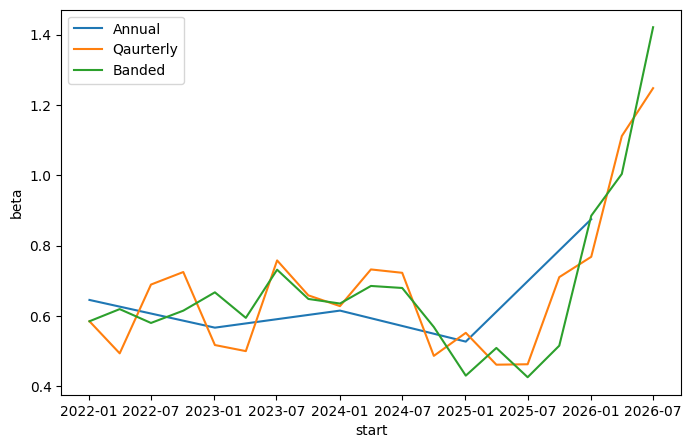

In [132]:
plt.figure(figsize = (8,5))
sns.lineplot(data = annual_weighted_beta_df, x = 'start', y = 'beta', label = 'Annual')
sns.lineplot(data = quarter_weighted_beta_df, x = 'start', y = 'beta', label = 'Qaurterly')
sns.lineplot(data = band_weighted_beta_df, x = 'start', y = 'beta', label = 'Banded')
plt.legend()

In [133]:
quarterly_regression_data = quarterly_value_adjusted.merge(spy_data, on = 'Date')

quarterly_regression_data['portfolio_excess'] = quarterly_regression_data['portfolio_return'] - quarterly_regression_data['rf_rate']
quarterly_regression_data['market_excess'] = quarterly_regression_data['SPY'] - quarterly_regression_data['rf_rate']

quarterly_model = smf.ols(formula= 'portfolio_excess~market_excess', data = quarterly_regression_data).fit()

exp_return_quarterly_ts = quarterly_regression_data['rf_rate'] + quarterly_model.params.iloc[1] * (quarterly_regression_data['SPY']-quarterly_regression_data['rf_rate'])
exp_return_quarterly = quarterly_regression_data['rf_rate'].mean() + quarterly_model.params.iloc[1] * (
    quarterly_regression_data['SPY'].mean()-quarterly_regression_data['rf_rate'].mean())

real_return_quarterly = quarterly_regression_data['portfolio_return'].mean()

jensens_alpha= real_return_quarterly - exp_return_quarterly

quarterly_table = pd.DataFrame([['Quarterly', quarterly_model.params.iloc[1], exp_return_quarterly, real_return_quarterly, jensens_alpha, model.rsquared]], 
                          columns = ['strategy','beta','capm_expected','real_return','jensen_alpha', 'R_squared'])

In [134]:
def regression_analysis(strategy, portfolii_df, benchmark_df):

    regression_data = portfolii_df.merge(benchmark_df, on = 'Date')

    regression_data['portfolio_excess'] = regression_data['portfolio_return'] - regression_data['rf_rate']
    regression_data['market_excess'] = regression_data['SPY'] - regression_data['rf_rate']

    model = smf.ols(formula= 'portfolio_excess~market_excess', data = regression_data).fit()

    exp_return_ts = regression_data['rf_rate'] + model.params.iloc[1] * (regression_data['SPY']-regression_data['rf_rate'])
    exp_return = regression_data['rf_rate'].mean() + model.params.iloc[1] * (
        regression_data['SPY'].mean()-regression_data['rf_rate'].mean())
    
    real_return = regression_data['portfolio_return'].mean()

    jensens_a = real_return - exp_return

    table = pd.DataFrame([[strategy, model.params.iloc[1], exp_return, real_return, jensens_a, model.rsquared]], 
                          columns = ['strategy','beta','capm_expected','real_return','jensen_alpha' ,'R_squared'])

    return table, model

In [ ]:
annual_table, annual_model = regression_analysis('Annual', annual_value_adjusted, spy_data)
band_table, band_model = regression_analysis('Band', band_value_adjusted, spy_data)
CAPM_table = pd.concat([annual_table, quarterly_table, band_table])

,strategy,beta,capm_expected,real_return,jensen_alpha,R_squared
0,Annual,0.617370,0.000386,0.000358,-0.000028,0.789502
0,Quarterly,0.607023,0.000383,0.000397,0.000015,0.779589
0,Band,0.610285,0.000384,0.000390,0.000006,0.794056


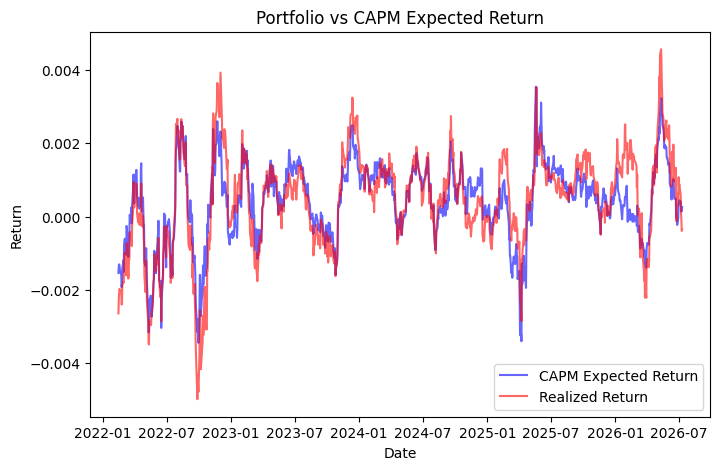

In [136]:

graph_data = quarterly_regression_data.copy()
graph_data['exp_return'] = exp_return_quarterly_ts
rolling_port_ret = graph_data['portfolio_return'].rolling(30).mean()
rolling_exp_ret = graph_data['exp_return'].rolling(30).mean()
date = graph_data['Date']
test = pd.concat([date, rolling_port_ret, rolling_exp_ret], axis = 1)

fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(data=test, x="Date", y="exp_return", alpha=0.6, color = 'blue', label="CAPM Expected Return", ax=ax)
sns.lineplot(data=test, x="Date", y="portfolio_return", alpha=0.6, color = 'red', label="Realized Return", ax=ax)

ax.set_xlabel("Date")
ax.set_ylabel("Return")
ax.set_title("Portfolio vs CAPM Expected Return")

ax.legend()
plt.show()

In [171]:
## Treynor Ratio ##
rf_rate = annual_value_adjusted['rf_rate'].mean() #RF Rate should be the same for every value df

CAPM_table['treynor_ratio'] = ( CAPM_table['real_return'] - rf_rate ) / CAPM_table['beta']


In [172]:
test = annual_value_adjusted.merge(
    spy_data,
    on = 'Date'
)
test['portfolio_return'] - test['SPY']

0      -0.010669
1      -0.000893
2       0.004896
3      -0.000213
4      -0.000273
          ...   
1128    0.000073
1129   -0.006002
1130    0.001496
1131   -0.000527
1132   -0.003915
Length: 1133, dtype: float64

In [173]:
## Tracking Error ##

def tracking_error(strategy, portfolio_df, asset_df, benchmark):
    portfolio_df = portfolio_df.merge(
        asset_df[['Date', benchmark]],
        on = 'Date'
    )
    active_returns = portfolio_df['portfolio_return'] - portfolio_df[benchmark]
    centered_active_returns = active_returns - active_returns.mean()
    returns_sq = (centered_active_returns**2).sum()
    number_of_periods = active_returns.count()
    te = np.sqrt(returns_sq/(number_of_periods -1))

    ir = active_returns.mean() / te

    table = pd.DataFrame([[strategy, te, ir]], columns= ['strategy', 'tracking_error', 'info_ratio'])

    return table


In [174]:

te_annual = tracking_error('Annual', annual_value_adjusted, spy_data, 'SPY')
te_quarterly = tracking_error('Quarterly', quarterly_value_adjusted, spy_data, 'SPY')
te_band = tracking_error('Band', band_value_adjusted, spy_data, 'SPY')
te_table = pd.concat([te_annual, te_quarterly, te_band])

In [175]:
summary_table = CAPM_table.merge(
    te_table,
    on = 'strategy'
)

In [176]:
summary_table

,strategy,beta,capm_expected,real_return,jensen_alpha,R_squared,treynor_ratio,tracking_error,info_ratio
0,Annual,0.617370,0.000386,0.000358,-0.000028,0.789502,0.000314,0.005515,-0.030111
1,Quarterly,0.607023,0.000383,0.000397,0.000015,0.779589,0.000384,0.005631,-0.022523
2,Band,0.610285,0.000384,0.000390,0.000006,0.794056,0.000370,0.005520,-0.024340
